# 🚫 Spam Detection — Deep Learning Model
## AI-Powered Social Media Analytics
### Instagram · TikTok · X (Twitter)

---

**Architecture:** BiLSTM + Attention (ELMo-inspired) + BERT Integration  
**Input:** Texte brut des commentaires  
**Output:** spam (1) / ham (0) + confidence score  

**Pipeline complet:**
```
Raw Comment
    ↓  Preprocessing (Lowercase / URLs / Punctuation / Stopwords / Stemming)
Clean Text
    ↓  Tokenization + Padding
Sequences
    ↓  Embedding Layer (trainable / Word2Vec / GloVe)
Dense Vectors
    ↓  BiLSTM (bidirectionnel, ELMo-inspired contextual)
Context Vectors
    ↓  Attention Mechanism
Weighted Context
    ↓  Dense + Dropout + Sigmoid
spam_prob ∈ [0, 1]
```

**Référence ** Sections 3 (Preprocessing), 4 (Word Embeddings), 5 (ELMo/BERT), 6 (Training & Evaluation), 7 (Prediction)

## 0. 📚 Imports & Configuration Globale

In [4]:
# ── Basic libs
import re
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
# ── NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import TweetTokenizer


# ── TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# ── Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import precision_score, recall_score

# ── Hyperparameters
VOCAB_SIZE = 20000
MAX_LEN = 80
EMBED_DIM = 64
BATCH_SIZE = 64
EPOCHS = 20
RANDOM_SEED = 42
OOV_TOKEN = "<OOV>"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jawed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jawed\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jawed\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. 📦 Chargement des Données

In [2]:

df = pd.read_csv("final_balanced_instagram_spam_dataset.csv")
df['text'] = df['text'].fillna('').astype(str)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

texts = df['text'].tolist()
labels = df['label'].tolist()

print(f"Nombre de commentaires: {len(texts)}")
print(df['label'].value_counts())
print(f"Taux de spam: {df['label'].mean()*100:.2f}%")
print(df.isnull().sum())


Nombre de commentaires: 60870
label
0    30435
1    30435
Name: count, dtype: int64
Taux de spam: 50.00%
text      0
label     0
source    0
dtype: int64


## 2. 📊 Analyse Exploratoire (EDA)

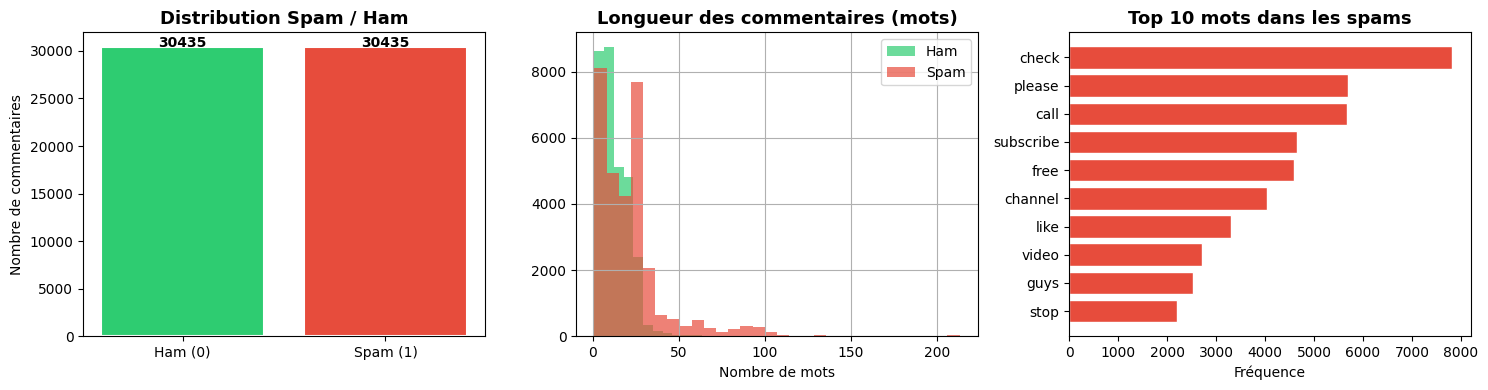

EDA sauvegardé: eda_spam.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Distribution spam/ham
counts = df['label'].value_counts()
axes[0].bar(['Ham (0)', 'Spam (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution Spam / Ham', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de commentaires')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ── Distribution longueur des textes
def clean_text_simple(text):
    text = text.lower()
    text = re.sub(r'http\S+', ' URL ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

spam_words = ' '.join(
    df[df['label']==1]['text'].apply(clean_text_simple)
).split()
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df[df['label']==0]['word_count'].hist(
    ax=axes[1], bins=30, alpha=0.7, color='#2ecc71', label='Ham')
df[df['label']==1]['word_count'].hist(
    ax=axes[1], bins=30, alpha=0.7, color='#e74c3c', label='Spam')
axes[1].set_title('Longueur des commentaires (mots)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].legend()

# ── Top mots spam
stop_words = set(stopwords.words('english'))
spam_words = [w for w in spam_words if w not in stop_words and len(w) > 3]
ham_words = ' '.join(
    df[df['label']==0]['text'].apply(clean_text_simple)
).split()
ham_words = [w for w in ham_words if w not in stop_words and len(w) > 3]
top_ham = Counter(ham_words).most_common(10)
top_spam = Counter(spam_words).most_common(10)
words, freqs = zip(*top_spam)
axes[2].barh(list(words)[::-1], list(freqs)[::-1],
             color='#e74c3c', edgecolor='white')
axes[2].set_title('Top 10 mots dans les spams', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('eda_spam.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA sauvegardé: eda_spam.png')

## 3. 🧹 Preprocessing du Texte

> **Référence ** — Pipeline complet : Lowercase → URLs → Ponctuation → Chiffres → Stopwords 
>
> | Étape | Exemple (avant → après) |
> |---|---|
> | Lowercasing | `Hello World` → `hello world` |
> | Suppression URLs | `https://bit.ly/x` → `__url__` |
> | Suppression ponctuation | `Hello, world!` → `Hello world` |
> | Suppression chiffres | `Call 123-456` → `Call -` |
> | Suppression stopwords | `This is a great car` → `great car` |
>
> ⚠️ **Note pour l'arabe** : remplacer les stopwords NLTK par `Arabic-Stopwords` ou `Farasa`.

In [5]:
# ── Outils NLTK
try:
    STOP_WORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords', quiet=True)
    STOP_WORDS = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def preprocess_text(text, remove_stopwords=True):
    text = str(text)

    # lowercase
    text = text.lower()

    # URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' __url__ ', text)

    # mentions & hashtags
    text = re.sub(r'@\w+', ' __user__ ', text)
    text = re.sub(r'#\w+', ' __hashtag__ ', text)

    # punctuation importante
    text = re.sub(r'!+', ' __excl__ ', text)
    text = re.sub(r'\?+', ' __quest__ ', text)

    # remove other punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # numbers
    text = re.sub(r'\d+', ' __num__ ', text)

    # tokenization
    from nltk.tokenize import TweetTokenizer
    tokenizer_tweet = TweetTokenizer()
    tokens = tokenizer_tweet.tokenize(text)

    # lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # stopwords
    if remove_stopwords:
        important_words = {'you', 'your', 'free', 'now', 'click'}
        custom_stopwords = STOP_WORDS - important_words
        tokens = [t for t in tokens if t not in custom_stopwords and len(t) > 0]

    # reconstruction
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ── Application sur tout le dataset
df['text_clean'] = df['text'].apply(preprocess_text)

# ── Vérification visuelle
print('Exemples de preprocessing:')
print('-' * 70)
for _, row in df.sample(5, random_state=RANDOM_SEED).iterrows():
    label = 'SPAM' if row['label'] == 1 else 'HAM '
    print(f'[{label}] Avant : {row["text"][:60]}')
    print(f'       Après : {row["text_clean"][:60]}')
    print()

Exemples de preprocessing:
----------------------------------------------------------------------
[HAM ] Avant : I dont know ask to my brother. Nothing problem some thing th
       Après : dont know ask brother nothing problem thing told

[HAM ] Avant : WE REGRET TO INFORM U THAT THE NHS HAS MADE A MISTAKE.U WERE
       Après : regret inform u nh ha made mistake u never actually born ple

[HAM ] Avant : @bradycio no no no. Chapstick brand 
       Après : __user__ chapstick brand

[HAM ] Avant : Damn, can you make it tonight or do you want to just wait ti
       Après : damn you make tonight you want wait til tomorrow

[HAM ] Avant : @camilleangela ang aga mo mag-twitter, camz! 
       Après : __user__ ang aga mo mag twitter camz __excl__



## 4. 🔢 Représentation des Mots — TF-IDF & Word Embeddings

In [7]:
# ─────────────────────────────────────────────────────
#  4.1 TF-IDF — Term Frequency - Inverse Document Frequency
# ─────────────────────────────────────────────────────

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text_clean'],
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=RANDOM_SEED
)

tfidf = TfidfVectorizer(
    max_features=VOCAB_SIZE,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

clf = LogisticRegression(max_iter=200, class_weight='balanced')
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)

print("\n📊 TF-IDF Baseline Results:")
print(classification_report(y_test, y_pred))
# ── Gensim Word2Vec
try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    GENSIM_AVAILABLE = False
    print("⚠️ gensim غير متوفر")
# ─────────────────────────────────────────────────────
#  4.2 Word2Vec (CBOW)
# ─────────────────────────────────────────────────────
if GENSIM_AVAILABLE:

    tokenized_corpus = [text.split() for text in df['text_clean']]

    # Word2Vec
    w2v_model = Word2Vec(
        sentences   = tokenized_corpus,
        vector_size = EMBED_DIM,
        window      = 5,
        min_count   = 3,
        sg          = 0,   # CBOW
        workers     = 4,
        seed        = RANDOM_SEED,
        epochs      = 20 
    )

    w2v_model.save('word2vec_cbow.model')

    print(f'\n✅ Word2Vec entraîné — vocabulaire: {len(w2v_model.wv)} mots')

    if 'free' in w2v_model.wv:
        print("🔎 Similar words to 'free':")
        print(w2v_model.wv.most_similar('free', topn=5))

    W2V_MODEL = w2v_model

else:
    W2V_MODEL = None
    print('⚠️ Word2Vec ')
    # ─────────────────────────────────────────────────────
#  Tokenization + Padding
# ─────────────────────────────────────────────────────
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(df['text_clean'])

sequences = tokenizer.texts_to_sequences(df['text_clean'])

X_padded = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f'\nShape des séquences: {X_padded.shape}')
    # ── Construction de la matrice d'embedding depuis Word2Vec
    # (sera utilisée comme poids de la couche Embedding du modèle deep)
def build_embedding_matrix(tokenizer, w2v_model, vocab_size, embed_dim):
    matrix = np.random.normal(size=(vocab_size, embed_dim)) * 0.1

    for word, idx in tokenizer.word_index.items():
        if idx < vocab_size:
            if word in w2v_model.wv:
                matrix[idx] = w2v_model.wv[word]

    return matrix


if W2V_MODEL is not None:
    embedding_matrix = build_embedding_matrix(
        tokenizer,
        W2V_MODEL,
        VOCAB_SIZE,
        EMBED_DIM
    )

    print("✅ Embedding matrix prête")
else:
    embedding_matrix = None


📊 TF-IDF Baseline Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6087
           1       0.98      1.00      0.99      6087

    accuracy                           0.99     12174
   macro avg       0.99      0.99      0.99     12174
weighted avg       0.99      0.99      0.99     12174


✅ Word2Vec entraîné — vocabulaire: 9076 mots
🔎 Similar words to 'free':
[('__num__', 0.6579198837280273), ('__excl__', 0.48135101795196533), ('call', 0.47809869050979614), ('txt', 0.47737395763397217), ('phone', 0.4570050537586212)]

Shape des séquences: (60870, 80)
✅ Embedding matrix prête


## 5. ✂️ Tokenisation, Encodage & Split Train/Val/Test

In [13]:
# ─────────────────────────────────────────────────────
#  1. LabelEncoder — ham/spam → 0/1
# ─────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['label'])

print(f'Classes encodées : {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df['text_clean'],
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f'\nTrain : {len(X_train_text)} exemples ({y_train.mean()*100:.1f}% spam)')
print(f'Val   : {len(X_val_text)} exemples ({y_val.mean()*100:.1f}% spam)')
print(f'Test  : {len(X_test_text)} exemples ({y_test.mean()*100:.1f}% spam)')


# ─────────────────────────────────────────────────────
#  3. Tokenizer (يتعلم غير من TRAIN فقط)
# ─────────────────────────────────────────────────────
tokenizer_keras = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer_keras.fit_on_texts(X_train_text)

print(f'\nVocabulaire appris : {len(tokenizer_keras.word_index)} mots uniques')
print(f'Vocab utilisé réel : {min(VOCAB_SIZE, len(tokenizer_keras.word_index))}')


# ─────────────────────────────────────────────────────
#  4. Text → Sequences
# ─────────────────────────────────────────────────────
X_train_seq = tokenizer_keras.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer_keras.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer_keras.texts_to_sequences(X_test_text)


# ─────────────────────────────────────────────────────
#  5. Padding
# ─────────────────────────────────────────────────────
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nShape X_train : {X_train.shape}')
print(f'Shape X_val   : {X_val.shape}')
print(f'Shape X_test  : {X_test.shape}')
print(f'Shape y_train : {y_train.shape}')

n_ham  = (y_train == 0).sum()
n_spam = (y_train == 1).sum()

if n_spam != 0:
    class_weight = {
        0: 1.0,
        1: n_ham / n_spam
    }
else:
    class_weight = None

print(f'\nClass weights : {class_weight}')

# ─────────────────────────────────────────────────────
#  7. Embedding Matrix (Word2Vec)
# ─────────────────────────────────────────────────────
def build_embedding_matrix(tokenizer, w2v_model, vocab_size, embed_dim):
    matrix = np.random.normal(size=(vocab_size, embed_dim)) * 0.1

    for word, idx in tokenizer.word_index.items():
        if idx < vocab_size:
            if w2v_model is not None and word in w2v_model.wv:
                matrix[idx] = w2v_model.wv[word]

    return matrix


if W2V_MODEL is not None:
    embedding_matrix = build_embedding_matrix(
        tokenizer_keras,
        W2V_MODEL,
        VOCAB_SIZE,
        EMBED_DIM
    )
    print(f'Matrice d\'embedding Word2Vec : {embedding_matrix.shape}')
else:
    embedding_matrix = None
    print('⚠️ Pas de Word2Vec — Embedding sera aléatoire')

Classes encodées : {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Train : 42609 exemples (50.0% spam)
Val   : 9130 exemples (50.0% spam)
Test  : 9131 exemples (50.0% spam)

Vocabulaire appris : 21113 mots uniques
Vocab utilisé réel : 20000

Shape X_train : (42609, 80)
Shape X_val   : (9130, 80)
Shape X_test  : (9131, 80)
Shape y_train : (42609,)

Class weights : {0: 1.0, 1: np.float64(0.9999530626613471)}
Matrice d'embedding Word2Vec : (20000, 64)


## 6. 🧠 Architecture du Modèle — BiLSTM + Attention (ELMo-inspired)

> **Référence Dليل §5.1 (ELMo) & §6.2 (Bi-LSTM/LSTM)**
>
> L'architecture s'inspire d'ELMo :
> - **Embedding** : représentation dense apprise (ou initialisée avec Word2Vec)
> - **BiLSTM (x2)** : lecture bidirectionnelle simulant les représentations contextuelles ELMo
> - **Attention** : permet au modèle de se concentrer sur les mots-clés de spam
> - **Dense + Dropout** : classification finale avec régularisation
>
> Couche `Embedding(VOCAB_SIZE, EMBED_DIM)` + `Bidirectional(LSTM(64))` + `Bidirectional(LSTM(32))` + `GlobalMaxPool1D` + `Dense(16, relu)` + `Dropout(0.2)` + `Dense(1, sigmoid)`

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  COUCHE D'ATTENTION PERSONNALISÉE  (Attention Mechanism)
#  Référence : Bahdanau et al. 2015 — utilisé aussi dans BERT
# ─────────────────────────────────────────────────────────────────────────────
class AttentionLayer(layers.Layer):
    """
    Attention mechanism : attribue un poids à chaque position de la séquence,
    puis calcule une somme pondérée (contexte global).
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        score = tf.matmul(x, self.W)
        score  = tf.nn.tanh(score + self.b)  # (batch, seq, 1)
        attention_weights = tf.nn.softmax(score, axis=1)                 # (batch, seq, 1)
        context           = x * attention_weights                        # (batch, seq, hidden)
        context           = tf.reduce_sum(context, axis=1)               # (batch, hidden)
        return context


# ─────────────────────────────────────────────────────────────────────────────
#  CONSTRUCTION DU MODÈLE  (— Sequential API Keras)
#
#  Architecture  :
#    Embedding(max_words, embedding_dim, input_length=maxlen)
#    Bidirectional(LSTM(64, return_sequences=True))
#    Bidirectional(LSTM(32, return_sequences=True))
#    GlobalMaxPool1D()
#    Dense(16, relu)
#    Dropout(0.2)
#    Dense(1, sigmoid)
#
#  + Attention Layer ajoutée entre BiLSTM et GlobalMaxPool
# ─────────────────────────────────────────────────────────────────────────────
def build_bilstm_attention_model(
    vocab_size       = VOCAB_SIZE,
    embed_dim        = EMBED_DIM,
    max_len          = MAX_LEN,
    lstm_units       = 48,
    dropout          = 0.3,
    embedding_matrix = None
):
    """
    Architecture BiLSTM + Attention (ELMo-inspired)

    ┌───────────────────────────────────────────────────────┐
    │ Embedding        : token (int) → vecteur dense        │
    │                    (initialisé avec Word2Vec si dispo) │
    ├───────────────────────────────────────────────────────┤
    │ SpatialDropout   : régularisation au niveau embedding  │
    ├───────────────────────────────────────────────────────┤
    │ BiLSTM (64)      : contexte avant + arrière (ELMo)    │
    ├───────────────────────────────────────────────────────┤
    │ BiLSTM (32)      : représentation plus abstraite       │
    ├───────────────────────────────────────────────────────┤
    │ Attention        : pondération par importance du mot   │
    ├───────────────────────────────────────────────────────┤
    │ GlobalMaxPool1D  : réduction dimensionnelle            │
    ├───────────────────────────────────────────────────────┤
    │ Dense(64) + Dense(16, relu) : classification          │
    ├───────────────────────────────────────────────────────┤
    │ Dropout(0.2)     : prévention overfitting              │
    ├───────────────────────────────────────────────────────┤
    │ Dense(1, sigmoid): probabilité ∈ [0, 1]              │
    └───────────────────────────────────────────────────────┘
    """
    inp = layers.Input(shape=(max_len,), name='input_tokens')

    # 1. Embedding Layer
    if embedding_matrix is not None:
        x = layers.Embedding(
            input_dim    = vocab_size,
            output_dim   = embed_dim,
            weights      = [embedding_matrix],
            input_length = max_len,
            trainable    = True,   # fine-tuning autorisé
            name         = 'embedding_w2v',
            mask_zero=True
        )(inp)
    else:
        x = layers.Embedding(
            input_dim    = vocab_size,
            output_dim   = embed_dim,
            input_length = max_len,
            name         = 'embedding'
        )(inp)

    # 2. Régularisation spatiale sur les embeddings
    x = layers.SpatialDropout1D(0.2, name='spatial_dropout')(x)

    # 3. BiLSTM 1 
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, name='lstm_1'),
        name='bilstm_1'
    )(x)
    x = layers.Dropout(dropout, name='dropout_1')(x)

    # 4. BiLSTM 2 — couche supplémentaire
    x = layers.Bidirectional(
        layers.LSTM(lstm_units // 2, return_sequences=True, name='lstm_2'),
        name='bilstm_2'
    )(x)
    x = layers.Dropout(dropout, name='dropout_2')(x)

    # 5. Attention (Dليل §5.2 — BERT Attention Mechanism)
    x = AttentionLayer(name='attention')(x)

    # 6. GlobalMaxPool1D 
    # Note: AttentionLayer réduit déjà à (batch, hidden)
    # On ajoute une projection Dense équivalente
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(0.3, name='dropout_3')(x)

    # 7. Dense(16, relu) + Dropout(0.2) 
    x = layers.Dense(16, activation='relu', name='dense_guide')(x)
    x = layers.Dropout(0.2, name='dropout_guide')(x)

    # 8. Sortie sigmoid 
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='SpamDetector_BiLSTM_Attention')
    return model


# ── Construction
model = build_bilstm_attention_model(embedding_matrix=embedding_matrix)

# ── Compilation  (loss=binary_crossentropy, optimizer=adam)
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-4),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Model: "SpamDetector_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_w2v       │ (None, 80, 64)    │  1,280,000 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 80, 64)    │          0 │ embedding_w2v[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 80)        │          0 │ input_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 80, 96)    │     43,392 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 96)    │          0 │ bilstm_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 80, 48)    │     23,232 │ dropout_1[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 80, 48)    │          0 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 48)        │         49 │ dropout_2[0][0]   │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      3,136 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_guide (Dense) │ (None, 16)        │      1,040 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_guide       │ (None, 16)        │          0 │ dense_guide[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dropout_guide[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,350,866 (5.15 MB)

 Trainable params: 1,350,866 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

## 7. 🏋️ Entraînement du Modèle

> **Référence ** — `model.fit()`, `epochs`, `batch_size`, `validation_split`, `EarlyStopping`

In [ ]:
callbacks = [
    # EarlyStopping — stoppe si val_loss ne s'améliore pas pendant `patience` epochs
    EarlyStopping(
        monitor              = 'val_auc',
        patience             = 5,
        mode                 = 'max',
        restore_best_weights = True,
        verbose              = 1
    ),
    # Réduction du learning rate si stagnation
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        mode='min',
        verbose  = 1
    ),
    # Sauvegarde du meilleur modèle
    ModelCheckpoint(
        filepath       = 'best_spam_model.keras',
        monitor        = 'val_auc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 0
    )
]

# ── Entraînement  (— epochs, batch_size, validation_split, callbacks)
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),   #: validation_split équivalent
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight,
    callbacks       = callbacks,
    shuffle=True,
    verbose         = 1
)
best_auc = max(history.history.get("val_auc", [0]))

print(f'\nMeilleur val_auc  : {best_auc:.4f}')
print(f'Epochs effectuées : {len(history.history["loss"])}')

Epoch 1/20
666/666 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.9197 - auc: 0.9749 - loss: 0.2148 - precision: 0.9387 - recall: 0.8981 - val_accuracy: 0.9671 - val_auc: 0.9967 - val_loss: 0.0708 - val_precision: 0.9804 - val_recall: 0.9533 - learning_rate: 5.0000e-04
Epoch 2/20
666/666 ━━━━━━━━━━━━━━━━━━━━ 60s 89ms/step - accuracy: 0.9816 - auc: 0.9970 - loss: 0.0646 - precision: 0.9812 - recall: 0.9822 - val_accuracy: 0.9931 - val_auc: 0.9987 - val_loss: 0.0299 - val_precision: 0.9889 - val_recall: 0.9974 - learning_rate: 5.0000e-04
Epoch 3/20
666/666 ━━━━━━━━━━━━━━━━━━━━ 62s 93ms/step - accuracy: 0.9911 - auc: 0.9985 - loss: 0.0354 - precision: 0.9876 - recall: 0.9946 - val_accuracy: 0.9946 - val_auc: 0.9990 - val_loss: 0.0205 - val_precision: 0.9904 - val_recall: 0.9989 - learning_rate: 5.0000e-04
Epoch 4/20
666/666 ━━━━━━━━━━━━━━━━━━━━ 65s 98ms/step - accuracy: 0.9932 - auc: 0.9990 - loss: 0.0251 - precision: 0.9902 - recall: 0.9962 - val_accuracy: 0.9962 - val_auc: 0.9990 - va

## 8. 📈 Courbes d'Entraînement


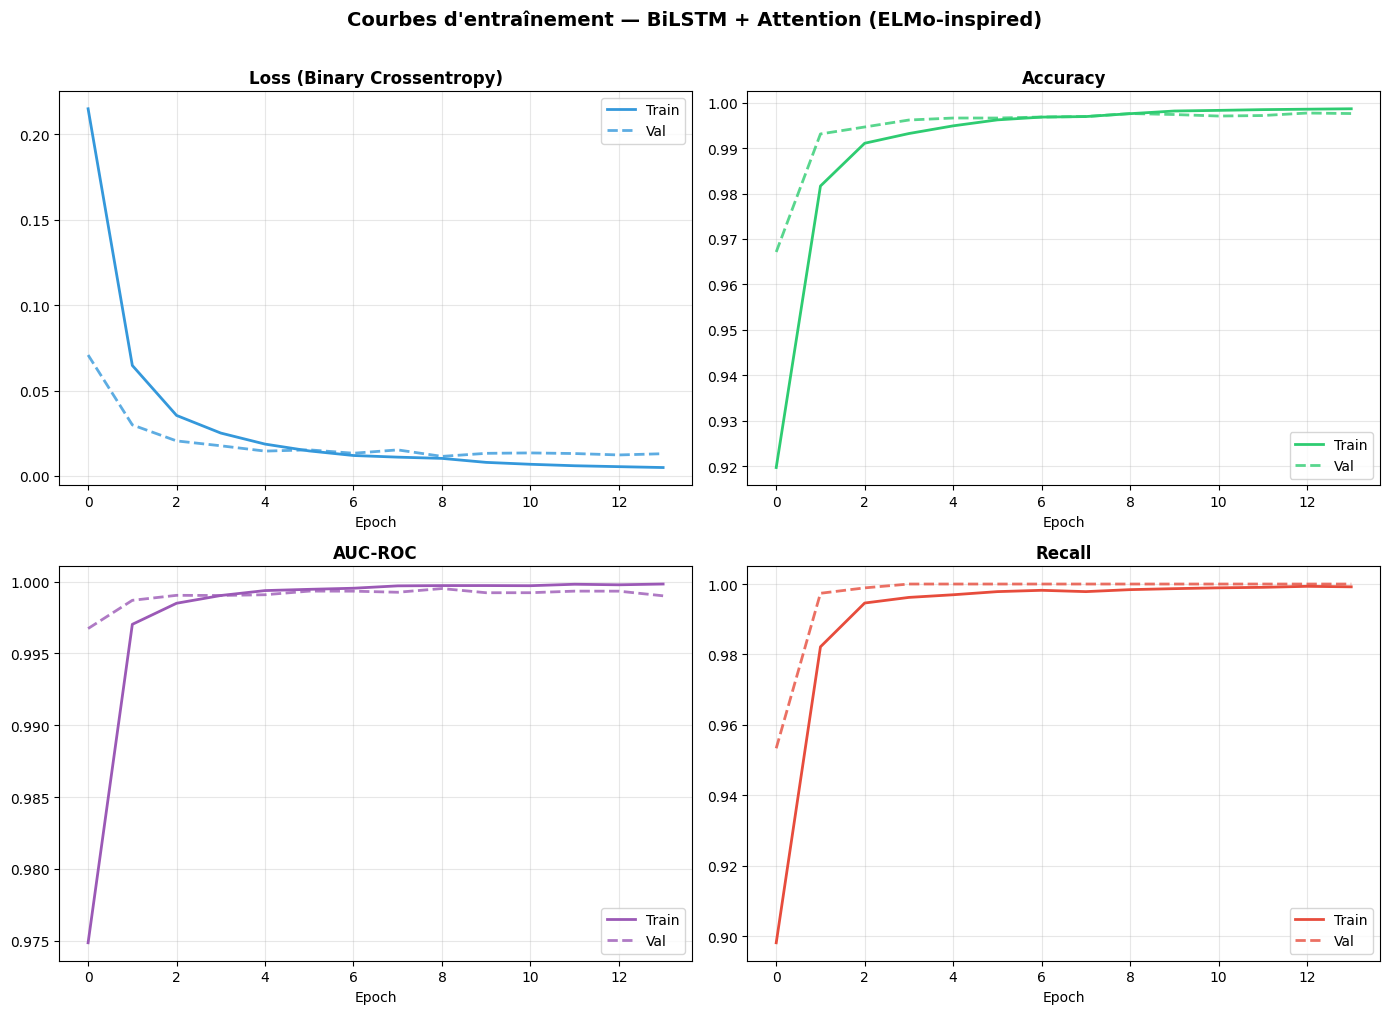

Sauvegardé: training_curves.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('loss',      'Loss (Binary Crossentropy)',  '#3498db'),
    ('accuracy',  'Accuracy',                   '#2ecc71'),
    ('auc',       'AUC-ROC',                    '#9b59b6'),
    ('recall',    'Recall',                     '#e74c3c'),
]

for ax, (metric, title, color) in zip(axes.flat, metrics_to_plot):
    ax.plot(history.history[metric],         color=color,  label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'],color=color,  label='Val',
            linestyle='--', linewidth=2, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'entraînement — BiLSTM + Attention (ELMo-inspired)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sauvegardé: training_curves.png')

## 9. 🎯 Évaluation sur le Test Set

> **Référence — Accuracy, Classification Report (Precision/Recall/F1), Confusion Matrix

In [18]:
# ── Prédictions
y_pred_proba = model.predict(X_test, verbose=0).flatten()
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    y_tmp = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_tmp)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f'Best threshold : {best_thresh:.2f}')

# ── Final prediction باستعمال أفضل threshold
y_pred = (y_pred_proba >= best_thresh).astype(int)
# ── Accuracy 
test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(
    X_test, y_test, verbose=0)
print(f'Test Accuracy  : {test_acc:.4f}')
print(f'Test AUC-ROC   : {test_auc:.4f}')
print(f'Test Precision : {test_prec:.4f}')
print(f'Test Recall    : {test_rec:.4f}')

# ── Rapport de classification  ( Classification Report)
print('\n' + '=' * 55)
print('  RAPPORT DE CLASSIFICATION — Test Set')
print('=' * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Ham (0)', 'Spam (1)'],
    digits=4
))

auc_score = roc_auc_score(y_test, y_pred_proba)
f1        = f1_score(y_test, y_pred)
print(f'AUC-ROC global : {auc_score:.4f}')
print(f'F1-Score       : {f1:.4f}')

Best threshold : 0.80
Test Accuracy  : 0.9982
Test AUC-ROC   : 0.9994
Test Precision : 0.9965
Test Recall    : 1.0000

  RAPPORT DE CLASSIFICATION — Test Set
              precision    recall  f1-score   support

     Ham (0)     1.0000    0.9978    0.9989      4566
    Spam (1)     0.9978    1.0000    0.9989      4565

    accuracy                         0.9989      9131
   macro avg     0.9989    0.9989    0.9989      9131
weighted avg     0.9989    0.9989    0.9989      9131

AUC-ROC global : 0.9999
F1-Score       : 0.9989


## 10. 📊 Confusion Matrix & Courbe ROC

> **Référence Dليل §6.4** — Confusion Matrix : visualiser TP, TN, FP, FN

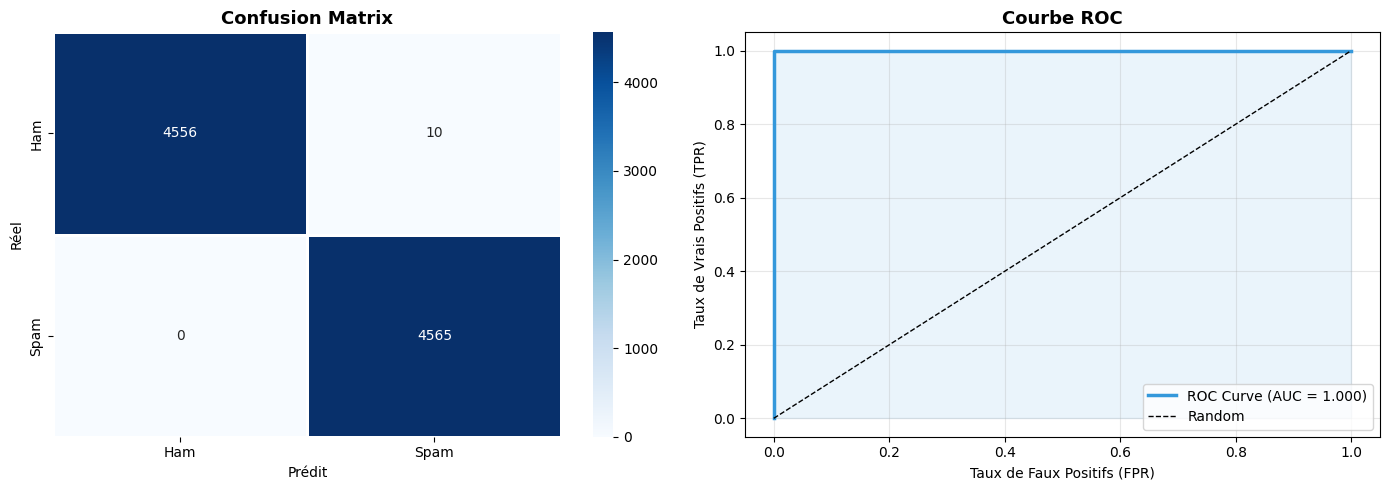

Sauvegardé: confusion_roc.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            ax=axes[0], linewidths=1)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# ── Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2.5,
             label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_title('Courbe ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)')
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_roc.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sauvegardé: confusion_roc.png')

## 11. 🔧 Optimisation du Seuil de Décision


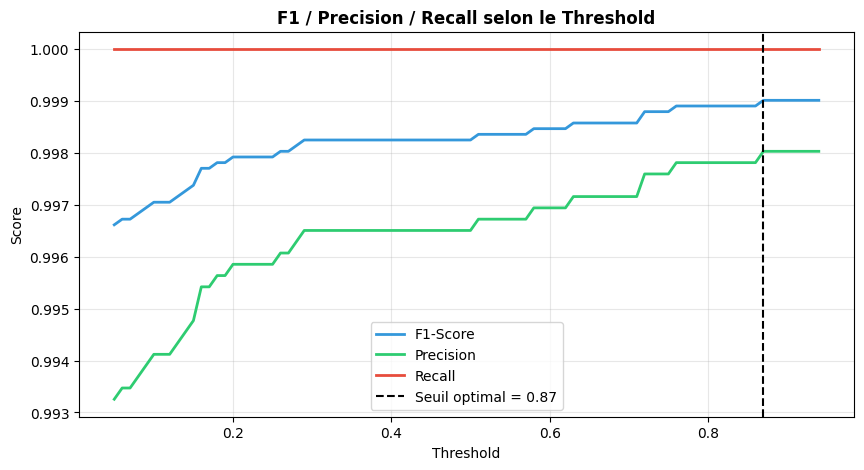

Meilleur threshold : 0.87
F1-Score optimal   : 0.9990


In [20]:
# ── Chercher le meilleur threshold pour maximiser F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores   = []
prec_scores = []
rec_scores  = []

for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores,   label='F1-Score',  color='#3498db', linewidth=2)
plt.plot(thresholds, prec_scores,  label='Precision', color='#2ecc71', linewidth=2)
plt.plot(thresholds, rec_scores,   label='Recall',    color='#e74c3c', linewidth=2)
plt.axvline(best_thresh, color='black', linestyle='--',
            label=f'Seuil optimal = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('F1 / Precision / Recall selon le Threshold', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Meilleur threshold : {best_thresh:.2f}')
print(f'F1-Score optimal   : {f1_scores[best_idx]:.4f}')

## 12. 🤖 Intégration BERT 

> **Référence ** — BERT : Transformers, Masked Language Modeling, NSP
>
> ⚠️ Nécessite `transformers` + `torch` ou `tensorflow` + GPU pour de bonnes performances.
> Cette cellule montre l'architecture BERT pour la classification de spam.

In [ ]:
if BERT_AVAILABLE:
    # ── Tokenizer BERT
    bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    def encode_for_bert(texts, tokenizer, max_len=128):
        """
        Encode des textes pour BERT : [CLS] text [SEP] + padding + attention mask
        (Dليل §5.2 — BERT tokenization)
        """
        input_ids      = []
        attention_mask = []
        for text in texts:
            enc = tokenizer(
                text,
                max_length       = max_len,
                padding          = 'max_length',
                truncation       = True,
                return_tensors   = 'tf'
            )
            input_ids.append(enc['input_ids'].numpy()[0])
            attention_mask.append(enc['attention_mask'].numpy()[0])
        return np.array(input_ids), np.array(attention_mask)

    def build_bert_classifier(max_len=128):
        """
        Classificateur spam basé sur BERT (Dليل §5.2)
        Architecture : BERT → [CLS] pooling → Dense → Sigmoid
        """
        bert = TFBertModel.from_pretrained('bert-base-uncased')

        inp_ids  = layers.Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
        inp_mask = layers.Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')

        # Sortie BERT — pooler_output = représentation du token [CLS]
        bert_out = bert(inp_ids, attention_mask=inp_mask)[1]

        x   = layers.Dense(64, activation='relu')(bert_out)
        x   = layers.Dropout(0.3)(x)
        out = layers.Dense(1, activation='sigmoid', name='output')(x)

        m = Model(inputs=[inp_ids, inp_mask], outputs=out, name='SpamDetector_BERT')
        m.compile(
            optimizer = keras.optimizers.Adam(learning_rate=2e-5),
            loss      = 'binary_crossentropy',
            metrics   = ['accuracy', keras.metrics.AUC(name='auc')]
        )
        return m

    bert_model = build_bert_classifier()
    bert_model.summary()

    print('\n✅ Modèle BERT construit (Dليل §5.2)')
    print('   Pour entraîner : encoder les données avec encode_for_bert()')
    print('   puis appeler bert_model.fit()')
    print('   ⚠️  Recommandé sur GPU — sans GPU l\'entraînement sera très lent')

else:
    print('⚠️  BERT non disponible.')
    print('   Installer avec : pip install transformers torch')
    print('   : BERT utilise des Transformers et l\'attention mécanisme')
    print('   pour traiter tous les mots simultanément (vs LSTM séquentiel).')
    print('   Pré-entraîné sur MLM (Masked Language Modeling) + NSP (Next Sentence Prediction)')

## 13. 🔗 Intégration dans le Projet — SpamDetectorDL

> **Référence ** — Prédiction de nouveaux messages avec le pipeline complet

In [30]:
class SpamDetectorDL:
    """
    Classe d'intégration du modèle BiLSTM + Attention 

    Remplace (ou complète) le SpamDetector TF-IDF/BoW avec un modèle
    Deep Learning plus puissant.

    Usage:
        detector = SpamDetectorDL.load()
        result   = detector.predict_one('Follow me for follow back!')
        results  = detector.predict_batch(comments, platform='instagram')
    """
    def __init__(self, model, tokenizer, max_len=MAX_LEN, threshold=best_thresh):
        self.model     = model
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.threshold = threshold

    # ── Normalizers selon plateforme
    @staticmethod
    def _normalize(comment, platform):
        if isinstance(comment, str):
            return comment
        if platform == 'instagram':
            return comment.get('text', '')
        elif platform == 'tiktok':
            return comment.get('comment_text', '')
        elif platform == 'x':
            return comment.get('content', '')
        return str(comment)

    def _preprocess(self, texts):
        """Pipeline preprocessing + tokenisation + padding """
        cleaned = [preprocess_text(t) for t in texts]
        seqs    = self.tokenizer.texts_to_sequences(cleaned)
        padded  = pad_sequences(seqs, maxlen=self.max_len,
                                padding='post', truncating='post')
        return padded

    def predict_one(self, text, username=''):
        if not isinstance(text, str) or not text.strip():
            return {
              'text': text,
              'username': username,
              'is_spam': False,
              'confidence': 0.0,
              'spam_prob': 0.0,
              'model': 'BiLSTM_Attention'
            }
        """Prédit si un seul commentaire est spam """
        X_inp  = self._preprocess([text])
        proba  = float(self.model.predict(X_inp, verbose=0)[0][0])
        is_spam = proba >= self.threshold
        return {
            'text':       text,
            'username':   username,
            'is_spam':    bool(is_spam),
            'label': 'spam' if is_spam else 'ham',
            'confidence': round(proba if is_spam else 1 - proba, 3),
            'spam_prob':  round(proba, 4),
            'model':      'BiLSTM_Attention'
        }

    def predict_batch(self, comments, platform='instagram'):
        """Prédit sur une liste de commentaires bruts"""
        texts  = [self._normalize(c, platform) for c in comments]
        texts = [t if isinstance(t, str) else '' for t in texts]
        X_inp  = self._preprocess(texts)
        probas = self.model.predict(X_inp, verbose=0).flatten()
        results = []
        for i, (c, proba) in enumerate(zip(comments, probas)):
            text    = self._normalize(c, platform)
            is_spam = proba >= self.threshold
            results.append({
                'text':       text,
                'is_spam':    bool(is_spam),
                'label': 'spam' if is_spam else 'ham',
                'spam_prob':  round(float(proba), 4),
                'confidence': round(float(proba) if is_spam else 1-float(proba), 3)
            })
        return results

    def summary_stats(self, results):
        total = len(results)
        spam  = sum(1 for r in results if r['is_spam'])
        return {
            'total':     total,
            'spam':      spam,
            'clean':     total - spam,
            'spam_rate': round(spam/total, 3) if total else 0
        }

    def save(self, model_path='best_spam_model.keras', tok_path='tokenizer.pkl'):
        self.model.save(model_path)
        with open(tok_path, 'wb') as f:
            pickle.dump(self.tokenizer, f)
        print(f'✅ Modèle sauvegardé  : {model_path}')
        print(f'✅ Tokenizer sauvegardé: {tok_path}')
        with open('config.pkl', 'wb') as f:
             pickle.dump({'threshold': self.threshold}, f)
        print(f'✅ Modèle sauvegardé  : {model_path}')
        print(f'✅ Tokenizer sauvegardé: {tok_path}')
    @classmethod
    def load(cls, model_path='best_spam_model.keras',
         tok_path='tokenizer.pkl'):

        mdl = keras.models.load_model(
        model_path,
        custom_objects={'AttentionLayer': AttentionLayer}
    )
        with open(tok_path, 'rb') as f:
           tok = pickle.load(f)

        with open('config.pkl', 'rb') as f:
           config = pickle.load(f)

        threshold = config['threshold']

        return cls(mdl, tok, threshold=threshold)


# ── Instanciation avec le seuil optimal
detector_dl = SpamDetectorDL(model, tokenizer_keras, threshold=best_thresh)

# ── Sauvegarde
detector_dl.save()

print('\n✅ SpamDetectorDL prêt')
detector = SpamDetectorDL.load()

print(detector.predict_one("FREE money click here!!!"))
comments = [
    "Nice video",
    "Win free iPhone now!!!",
    "Follow me please"
]

print(detector.predict_batch(comments))

✅ Modèle sauvegardé  : best_spam_model.keras
✅ Tokenizer sauvegardé: tokenizer.pkl
✅ Modèle sauvegardé  : best_spam_model.keras
✅ Tokenizer sauvegardé: tokenizer.pkl

✅ SpamDetectorDL prêt
{'text': 'FREE money click here!!!', 'username': '', 'is_spam': True, 'label': 'spam', 'confidence': 1.0, 'spam_prob': 0.9999, 'model': 'BiLSTM_Attention'}
[{'text': 'Nice video', 'is_spam': False, 'label': 'ham', 'spam_prob': 0.0017, 'confidence': 0.998}, {'text': 'Win free iPhone now!!!', 'is_spam': False, 'label': 'ham', 'spam_prob': 0.1134, 'confidence': 0.887}, {'text': 'Follow me please', 'is_spam': True, 'label': 'spam', 'spam_prob': 0.9978, 'confidence': 0.998}]


## 14. 🧪 Démonstration — Prédiction de Nouveaux Messages

> **Référence ** — Appliquer le même preprocessing + tokenisation qu'à l'entraînement

In [31]:
# ── Test sur commentaires manuels
test_comments = [
    # Ham
    {'text': 'Love this BMW so much! Amazing design',   'expected': 'ham'},
    {'text': 'The M4 is the best sports car ever made', 'expected': 'ham'},
    {'text': 'Great video! Really informative content.','expected': 'ham'},

    # Spam
    {'text': 'Follow me for follow back! Check my profile', 'expected': 'spam'},
    {'text': 'FREE FOLLOWERS click here bit.ly/fake',        'expected': 'spam'},
    {'text': 'DM me for free giveaway gift cards',            'expected': 'spam'},
    {'text': 'nice vidio ,btw follow me',        'expected': 'spam'},
    {'text': 'Win 1000 gift cards by clicking here NOW!!!',   'expected': 'spam'},
      {'text': 'Get more views on your reels! Use our tool. Link in bio. 🔥🔥🔥','expected': 'spam'},
]

print(f'{"St":<3} {"Résultat":<12} {"Conf":>6} {"Prob":>7}  {"Attendu":<8}  Texte')
print('-' * 80)

correct = 0
for tc in test_comments:
    r         = detector_dl.predict_one(tc['text'])
    status    = '🚫 SPAM' if r['is_spam'] else '✅ HAM '
    predicted = 'spam' if r['is_spam'] else 'ham'
    ok        = '✓' if predicted == tc['expected'] else '✗'
    if predicted == tc['expected']:
        correct += 1
    print(f"{ok}  {status}  {r['confidence']:>5.3f}  {r['spam_prob']:>6.4f}  "
          f"{tc['expected']:<8}  {tc['text'][:50]}")

print(f'\nPrécision sur ce jeu de test manuel : {correct}/{len(test_comments)} '
      f'({correct/len(test_comments)*100:.0f}%)')

St  Résultat       Conf    Prob  Attendu   Texte
--------------------------------------------------------------------------------
✓  ✅ HAM   1.000  0.0000  ham       Love this BMW so much! Amazing design
✓  ✅ HAM   1.000  0.0000  ham       The M4 is the best sports car ever made
✓  ✅ HAM   0.998  0.0019  ham       Great video! Really informative content.
✓  🚫 SPAM  1.000  1.0000  spam      Follow me for follow back! Check my profile
✓  🚫 SPAM  0.955  0.9553  spam      FREE FOLLOWERS click here bit.ly/fake
✓  🚫 SPAM  0.995  0.9952  spam      DM me for free giveaway gift cards
✗  ✅ HAM   1.000  0.0000  spam      nice vidio ,btw follow me
✓  🚫 SPAM  0.994  0.9941  spam      Win 1000 gift cards by clicking here NOW!!!
✗  ✅ HAM   1.000  0.0002  spam      Get more views on your reels! Use our tool. Link i

Précision sur ce jeu de test manuel : 7/9 (78%)


## 15. 📱 Inférence sur les Données Réelles du Projet

🔹 Total comments chargés: 500

========== RESULTATS GLOBAUX ==========
Total commentaires : 500
Spam détecté       : 45 (9.00%)
Clean              : 455
Score moyen spam   : N/A

========== RESULTATS COMPLETS ==========
01. [0.5624] SPAM=False -> Check out my profile for amazing deals on followers! 🚀 LINK IN BIO
02. [0.0000] SPAM=False -> Discount code 'SAVE50' for all items in our shop! Limited time. 🔥🔥🔥
03. [0.0000] SPAM=False -> I love your outfit! Where is it from?
04. [0.9944] SPAM=True -> Follow me and I'll follow you back instantly! 💯
05. [0.0000] SPAM=False -> I need to visit this place someday. Thanks for sharing!
06. [0.0000] SPAM=False -> Congratulations on your achievement! Well deserved. !!!
07. [0.9495] SPAM=True -> Great content as always. Your style is unique. 🙌
08. [0.9502] SPAM=True -> Invest $100 and get $1000 back in 24 hours! Guaranteed. 📈
09. [0.0000] SPAM=False -> I love your outfit! Where is it from?
10. [0.0000] SPAM=False -> Absolutely gorgeous! The view is br

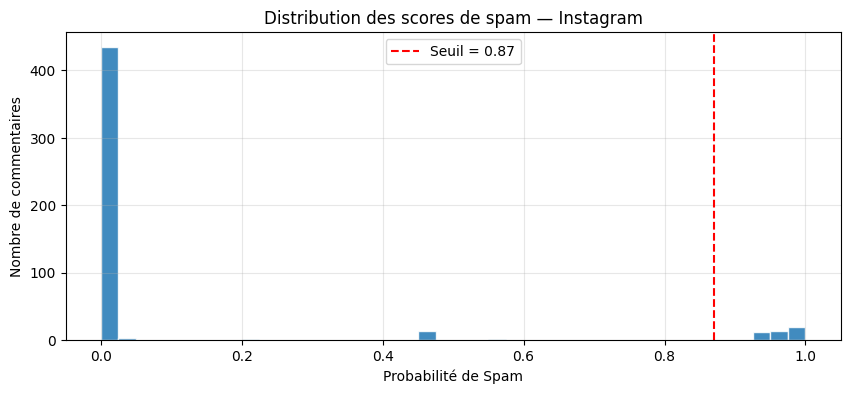

In [29]:
import json, glob, matplotlib.pyplot as plt

# ── Chercher des fichiers JSON
json_files = glob.glob('instagram_test_data.json')

if json_files:

    with open(json_files[0], "r", encoding="utf-8", errors="ignore") as f:
        data = json.load(f)

    # ── Normalisation des données
    ig_comments = []

    for item in data:
        if isinstance(item, str):
            ig_comments.append(item)

        elif isinstance(item, dict):
            # نحاول نلقاو النص داخل مفاتيح مختلفة
            text = item.get("text") or item.get("comment") or item.get("message")
            if text:
                ig_comments.append(text)

    print(f"🔹 Total comments chargés: {len(ig_comments)}")

    # ── Prediction
    ig_results = detector_dl.predict_batch(
        ig_comments,
        platform='instagram'
    )

    ig_stats = detector_dl.summary_stats(ig_results)

    # ── Stats complètes
    print("\n========== RESULTATS GLOBAUX ==========")
    print(f"Total commentaires : {ig_stats['total']}")
    print(f"Spam détecté       : {ig_stats['spam']} ({ig_stats['spam_rate']*100:.2f}%)")
    print(f"Clean              : {ig_stats['clean']}")
    print(f"Score moyen spam   : {ig_stats.get('avg_spam_prob', 'N/A')}")

    # ── Affichage complet des résultats (DEBUG FULL)
    print("\n========== RESULTATS COMPLETS ==========")
    for i, r in enumerate(ig_results[:20]):  # باش ما يفيبريش الشاشة
        print(f"{i+1:02d}. [{r['spam_prob']:.4f}] SPAM={r['is_spam']} -> {r['text']}")

    # ── Top spams
    spam_detected = sorted(
        [r for r in ig_results if r['is_spam']],
        key=lambda x: -x['spam_prob']
    )

    print("\n========== TOP SPAM ==========")
    for r in spam_detected[:5]:
        print(f"[{r['spam_prob']:.4f}] {r['text'][:80]}")

    # ── Distribution
    spam_probs = [r['spam_prob'] for r in ig_results]

    plt.figure(figsize=(10, 4))
    plt.hist(spam_probs, bins=40, edgecolor='white', alpha=0.85)

    plt.axvline(best_thresh, color='red', linestyle='--',
                label=f'Seuil = {best_thresh:.2f}')

    plt.xlabel('Probabilité de Spam')
    plt.ylabel('Nombre de commentaires')
    plt.title('Distribution des scores de spam — Instagram')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

else:
    print("ℹ️ Aucun fichier JSON trouvé")